# Clinical Trial Trends Explorer

Analyzing **10,000 clinical trials** from [ClinicalTrials.gov](https://clinicaltrials.gov) to identify trends in research focus, sponsor investment, trial phases, and geographic distribution.

**Data source:** ClinicalTrials.gov API v2 (no API key required)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 5)

Path("outputs").mkdir(exist_ok=True)

In [2]:
df = pd.read_csv("data/clinical_trials.csv")

# Parse start year
df["start_year"] = pd.to_datetime(df["start_date"], format="mixed", errors="coerce").dt.year

# Clean phase labels
phase_map = {
    "EARLY_PHASE1": "Early Phase 1",
    "PHASE1": "Phase 1",
    "PHASE2": "Phase 2",
    "PHASE3": "Phase 3",
    "PHASE4": "Phase 4",
}
df["phase_clean"] = df["phase"].map(phase_map).fillna("Not Specified")

# Clean sponsor type
sponsor_map = {
    "OTHER": "Academic/Other",
    "INDUSTRY": "Industry",
    "NIH": "NIH",
    "OTHER_GOV": "Government",
    "FED": "Government",
    "NETWORK": "Network",
    "INDIV": "Individual",
}
df["sponsor_clean"] = df["sponsor_type"].map(sponsor_map).fillna("Other")

# Flatten countries
df["primary_country"] = df["country"].str.split("|").str[0]

print(f"Loaded {len(df):,} clinical trials")
print(f"Date range: {int(df['start_year'].min())} – {int(df['start_year'].max())}")
df.head(3)

Loaded 10,000 clinical trials
Date range: 1973 – 2027


,nct_id,brief_title,overall_status,phase,study_type,start_date,completion_date,enrollment,condition,lead_sponsor,sponsor_type,country,start_year,phase_clean,sponsor_clean,primary_country
0,NCT00830635,Multimedia Educational Program for Patients Wi...,COMPLETED,NaN,INTERVENTIONAL,2008-09,2013-12,1800.0,Breast Cancer,"University of Colorado, Denver",OTHER,United States,2008.0,Not Specified,Academic/Other,United States
1,NCT04643535,In Vivo Glycocalyx as Predictor of Complicatio...,TERMINATED,NaN,OBSERVATIONAL,2020-11-30,2025-12-30,130.0,Endothelial Dysfunction,"University Hospital, Rouen",OTHER,France,2020.0,Not Specified,Academic/Other,France
2,NCT05920135,First-in-Human Study of BBT-207 in Advanced No...,ACTIVE_NOT_RECRUITING,PHASE1,INTERVENTIONAL,2023-09-11,2028-08-01,24.0,EGFR Mutant Advanced Non-Small Cell Lung Cancer,"Bridge Biotherapeutics, Inc.",INDUSTRY,South Korea,2023.0,Phase 1,Industry,South Korea


## 1. Trial Status Overview

What proportion of trials are completed vs still active?

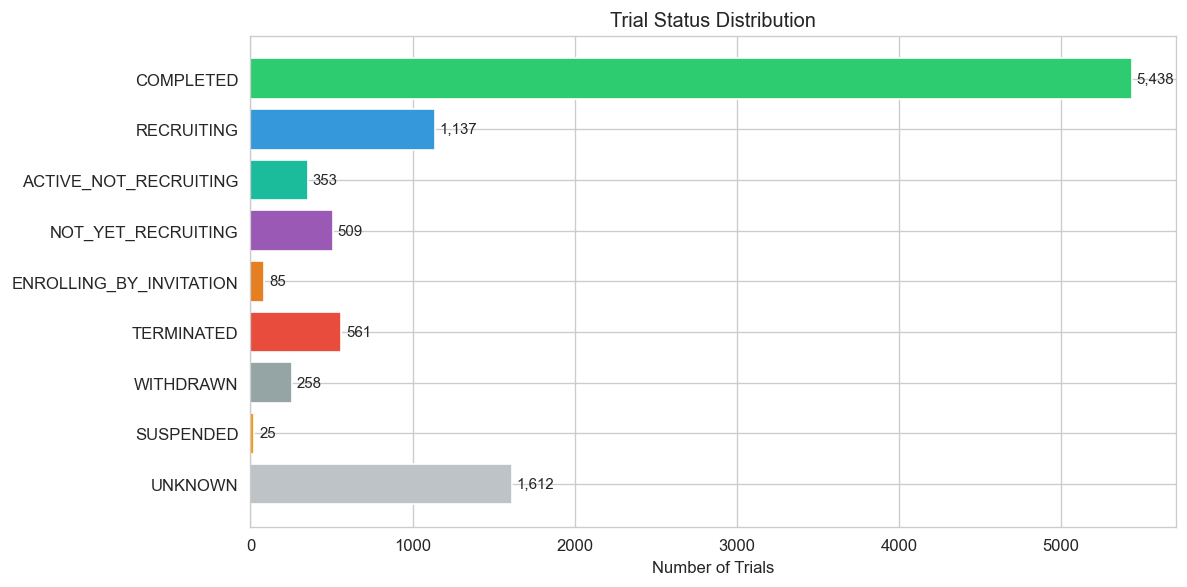

In [3]:
status_order = ["COMPLETED", "RECRUITING", "ACTIVE_NOT_RECRUITING", 
                "NOT_YET_RECRUITING", "ENROLLING_BY_INVITATION",
                "TERMINATED", "WITHDRAWN", "SUSPENDED", "UNKNOWN"]

status_counts = df["overall_status"].value_counts().reindex(status_order).dropna()

colors = ["#2ecc71", "#3498db", "#1abc9c", "#9b59b6", "#e67e22",
          "#e74c3c", "#95a5a6", "#f39c12", "#bdc3c7"]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(status_counts.index[::-1], status_counts.values[::-1], 
               color=colors[:len(status_counts)][::-1])
ax.set_xlabel("Number of Trials")
ax.set_title("Trial Status Distribution")

for bar in bars:
    width = bar.get_width()
    ax.text(width + 30, bar.get_y() + bar.get_height()/2, 
            f"{int(width):,}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("outputs/status_distribution.png", bbox_inches="tight")
plt.show()

## 2. Top Conditions Being Studied

Which diseases and conditions have the most active clinical research?

/var/folders/pb/nsrvrhmx5wl1w3zx82t7y55m0000gn/T/ipykernel_58199/75265679.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_conditions.values, y=top_conditions.index,


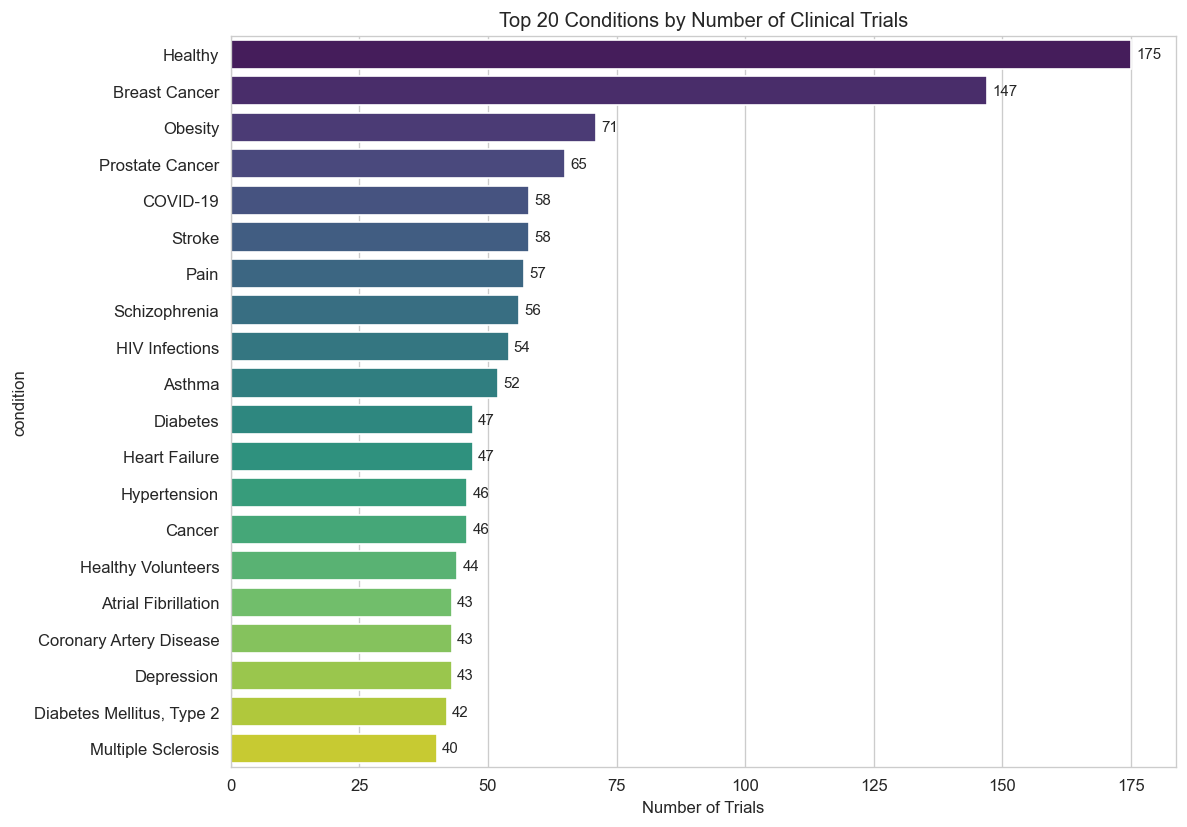

In [4]:
top_conditions = df["condition"].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(x=top_conditions.values, y=top_conditions.index, 
            palette="viridis", ax=ax)
ax.set_xlabel("Number of Trials")
ax.set_title("Top 20 Conditions by Number of Clinical Trials")

for i, v in enumerate(top_conditions.values):
    ax.text(v + 1, i, str(v), va="center", fontsize=9)

plt.tight_layout()
plt.savefig("outputs/top_conditions.png", bbox_inches="tight")
plt.show()

## 3. Trial Volume Over Time

How has the number of new trials changed over the past two decades?

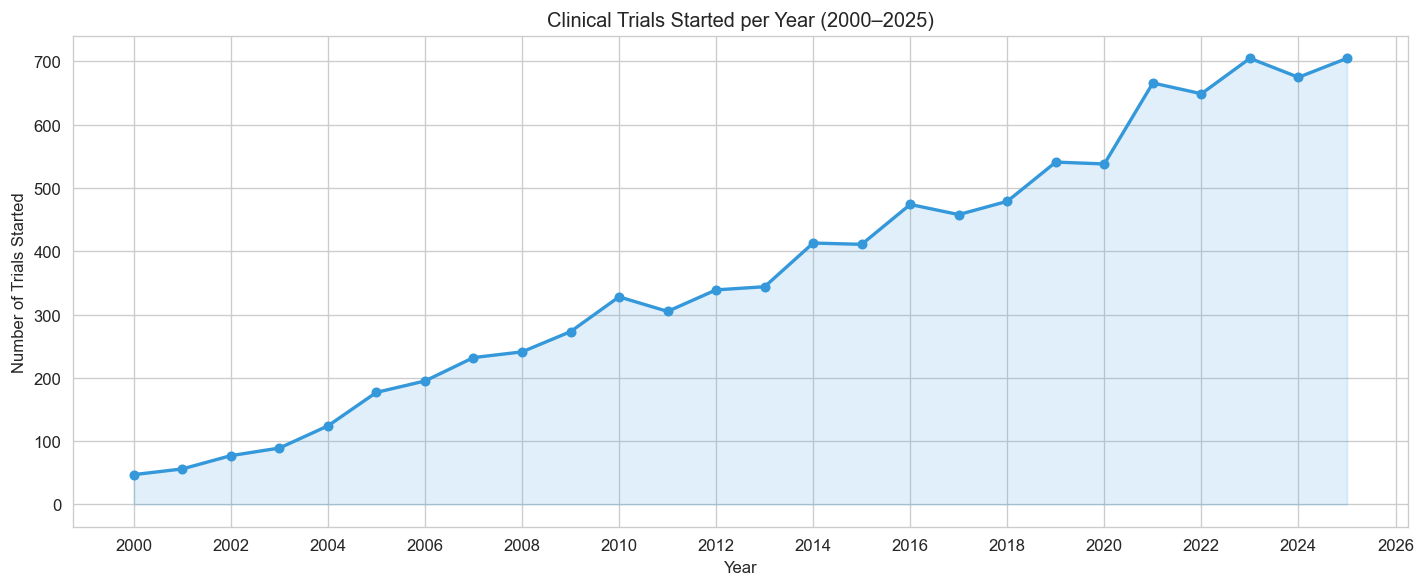

In [5]:
yearly = df[(df["start_year"] >= 2000) & (df["start_year"] <= 2025)].copy()
year_counts = yearly.groupby("start_year").size()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(year_counts.index, year_counts.values, marker="o", linewidth=2, 
        color="#3498db", markersize=5)
ax.fill_between(year_counts.index, year_counts.values, alpha=0.15, color="#3498db")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Trials Started")
ax.set_title("Clinical Trials Started per Year (2000–2025)")
ax.xaxis.set_major_locator(mtick.MultipleLocator(2))

plt.tight_layout()
plt.savefig("outputs/trials_over_time.png", bbox_inches="tight")
plt.show()

## 4. Phase Distribution

What phases of research are most common? The funnel from Phase 1 to Phase 4 shows the drug development pipeline.

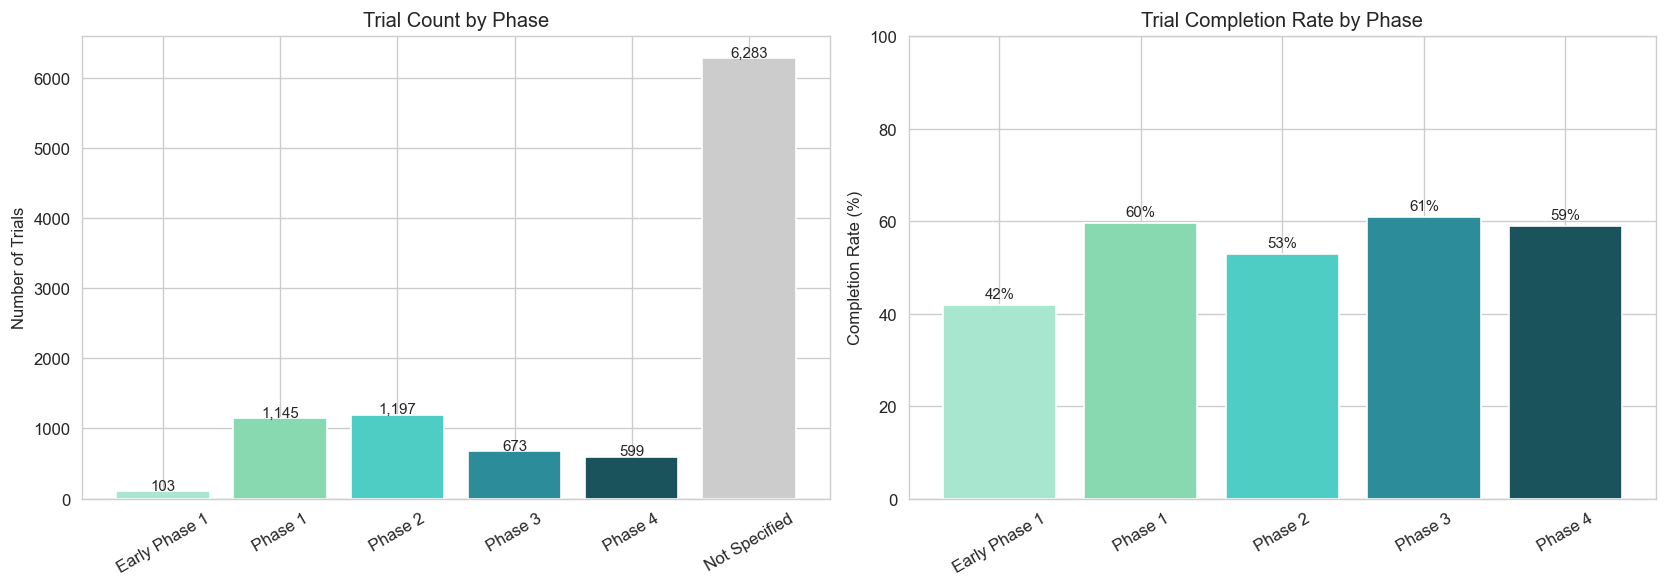

In [6]:
phase_order = ["Early Phase 1", "Phase 1", "Phase 2", "Phase 3", "Phase 4", "Not Specified"]
phase_counts = df["phase_clean"].value_counts().reindex(phase_order).dropna()

phase_colors = ["#a8e6cf", "#88d8b0", "#4ecdc4", "#2c8c99", "#1a535c", "#cccccc"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
ax1.bar(phase_counts.index, phase_counts.values, color=phase_colors)
ax1.set_ylabel("Number of Trials")
ax1.set_title("Trial Count by Phase")
ax1.tick_params(axis="x", rotation=30)

for i, v in enumerate(phase_counts.values):
    ax1.text(i, v + 20, f"{v:,}", ha="center", fontsize=9)

# Completion rate by phase
phase_status = df[df["phase_clean"] != "Not Specified"].groupby("phase_clean")["overall_status"].apply(
    lambda x: (x == "COMPLETED").mean() * 100
).reindex(["Early Phase 1", "Phase 1", "Phase 2", "Phase 3", "Phase 4"]).dropna()

ax2.bar(phase_status.index, phase_status.values, color=phase_colors[:len(phase_status)])
ax2.set_ylabel("Completion Rate (%)")
ax2.set_title("Trial Completion Rate by Phase")
ax2.tick_params(axis="x", rotation=30)
ax2.set_ylim(0, 100)

for i, v in enumerate(phase_status.values):
    ax2.text(i, v + 1.5, f"{v:.0f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("outputs/phase_distribution.png", bbox_inches="tight")
plt.show()

## 5. Industry vs Academic Sponsors

Who funds clinical research — pharmaceutical companies or academic institutions?

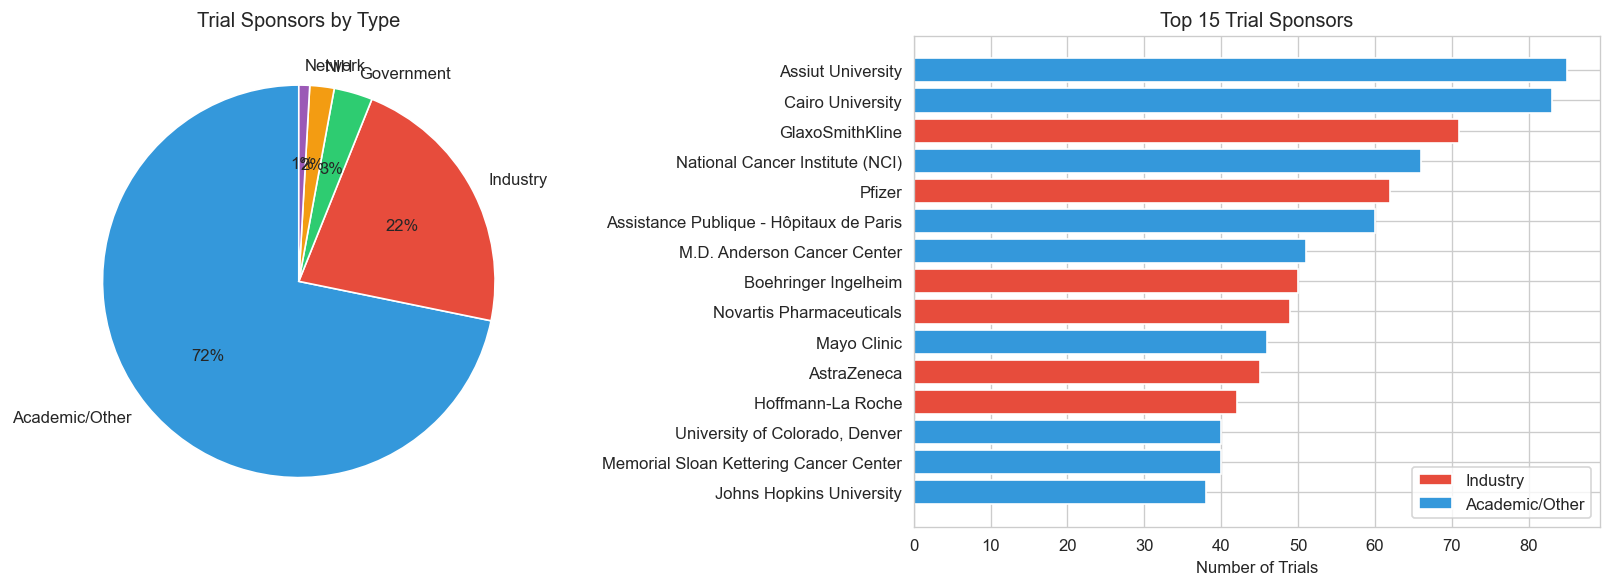

In [7]:
sponsor_counts = df["sponsor_clean"].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
main_sponsors = sponsor_counts[sponsor_counts > 50]
ax1.pie(main_sponsors.values, labels=main_sponsors.index, autopct="%1.0f%%",
        colors=["#3498db", "#e74c3c", "#2ecc71", "#f39c12", "#9b59b6"],
        startangle=90)
ax1.set_title("Trial Sponsors by Type")

# Top individual sponsors
top_sponsors = df["lead_sponsor"].value_counts().head(15)
colors_sponsor = ["#e74c3c" if df[df["lead_sponsor"] == name]["sponsor_clean"].iloc[0] == "Industry" 
                  else "#3498db" for name in top_sponsors.index]

ax2.barh(top_sponsors.index[::-1], top_sponsors.values[::-1], 
         color=colors_sponsor[::-1])
ax2.set_xlabel("Number of Trials")
ax2.set_title("Top 15 Trial Sponsors")

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#e74c3c", label="Industry"),
                   Patch(facecolor="#3498db", label="Academic/Other")]
ax2.legend(handles=legend_elements, loc="lower right")

plt.tight_layout()
plt.savefig("outputs/sponsors.png", bbox_inches="tight")
plt.show()

## 6. Industry vs Academic: Phase Focus

Do pharma companies and academic centers prioritize different phases of research?

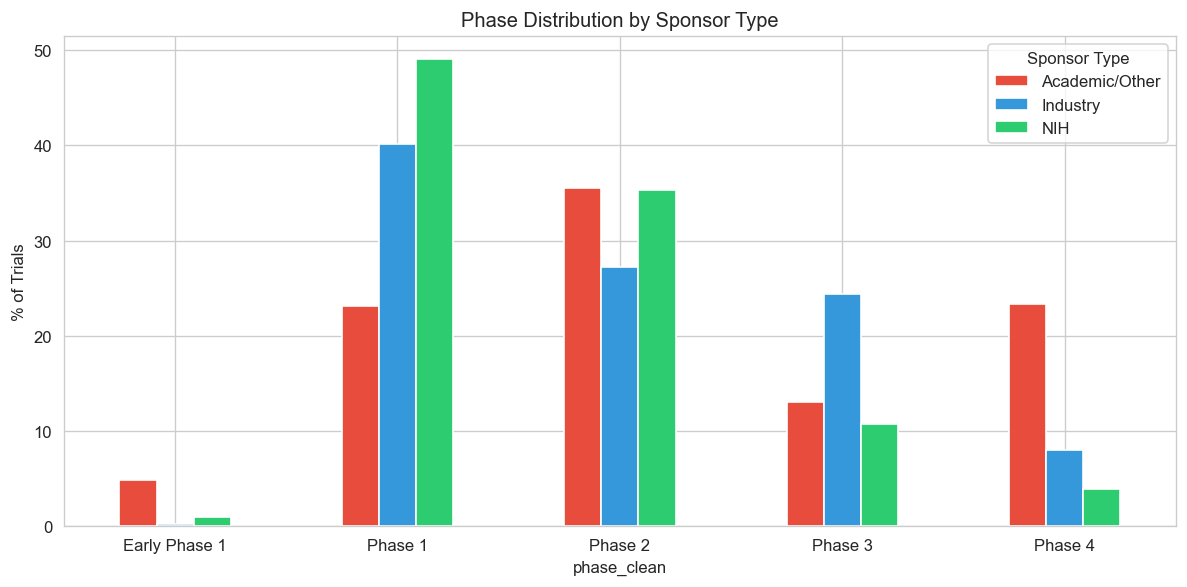

In [8]:
phase_by_sponsor = df[df["phase_clean"] != "Not Specified"].groupby(
    ["sponsor_clean", "phase_clean"]
).size().unstack(fill_value=0)

# Normalize to percentages
phase_pct = phase_by_sponsor.div(phase_by_sponsor.sum(axis=1), axis=0) * 100

# Focus on Industry vs Academic
main_types = ["Industry", "Academic/Other", "NIH"]
phase_order_clean = ["Early Phase 1", "Phase 1", "Phase 2", "Phase 3", "Phase 4"]
phase_pct_main = phase_pct.loc[
    phase_pct.index.isin(main_types), 
    phase_pct.columns.isin(phase_order_clean)
].reindex(columns=phase_order_clean)

fig, ax = plt.subplots(figsize=(10, 5))
phase_pct_main.T.plot(kind="bar", ax=ax, color=["#e74c3c", "#3498db", "#2ecc71"])
ax.set_ylabel("% of Trials")
ax.set_title("Phase Distribution by Sponsor Type")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Sponsor Type")

plt.tight_layout()
plt.savefig("outputs/phase_by_sponsor.png", bbox_inches="tight")
plt.show()

## 7. Geographic Distribution

Where are clinical trials conducted?

/var/folders/pb/nsrvrhmx5wl1w3zx82t7y55m0000gn/T/ipykernel_58199/684400347.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_counts.values, y=country_counts.index,


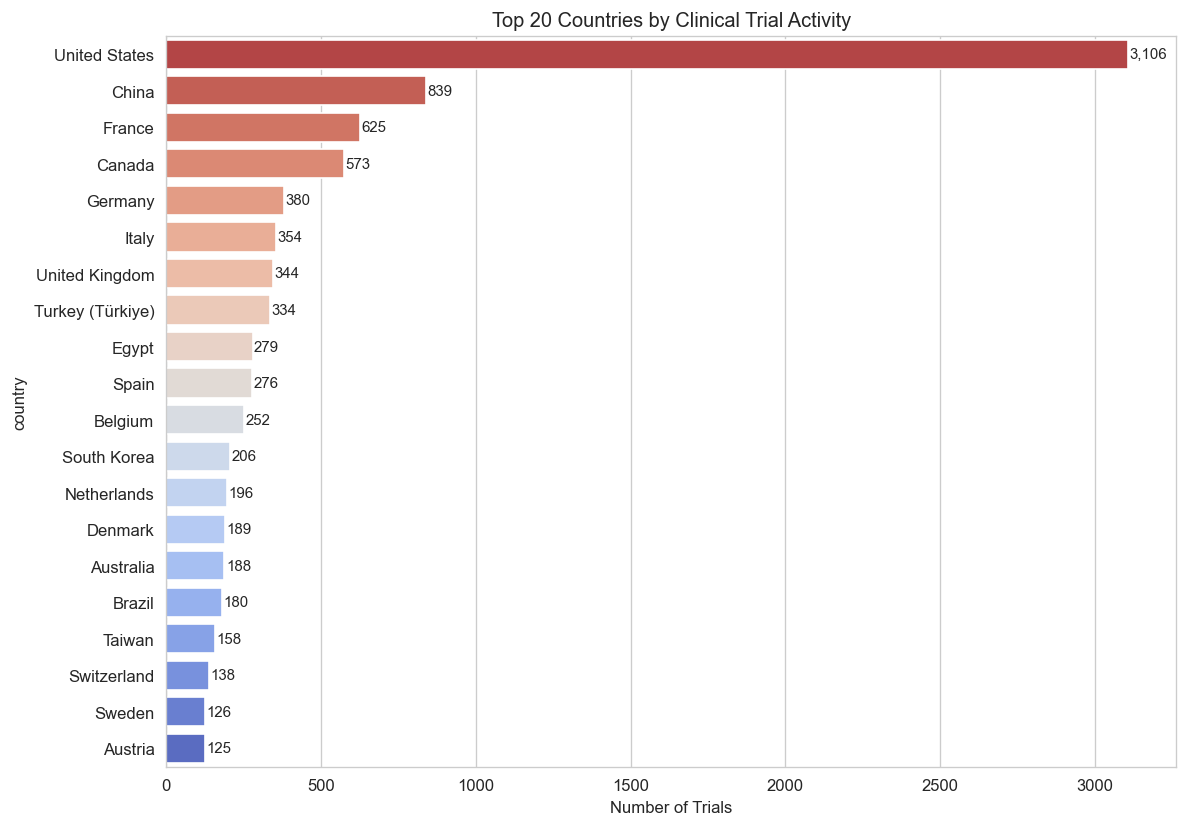

In [9]:
# Flatten multi-country entries and count
countries = df["country"].dropna().str.split("|").explode()
country_counts = countries.value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(x=country_counts.values, y=country_counts.index, 
            palette="coolwarm_r", ax=ax)
ax.set_xlabel("Number of Trials")
ax.set_title("Top 20 Countries by Clinical Trial Activity")

for i, v in enumerate(country_counts.values):
    ax.text(v + 5, i, f"{v:,}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("outputs/countries.png", bbox_inches="tight")
plt.show()

## 8. Enrollment Size by Phase

How does enrollment scale across phases? Later phases typically require larger patient populations.

/var/folders/pb/nsrvrhmx5wl1w3zx82t7y55m0000gn/T/ipykernel_58199/3398288932.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=enroll, x="phase_clean", y="enrollment",


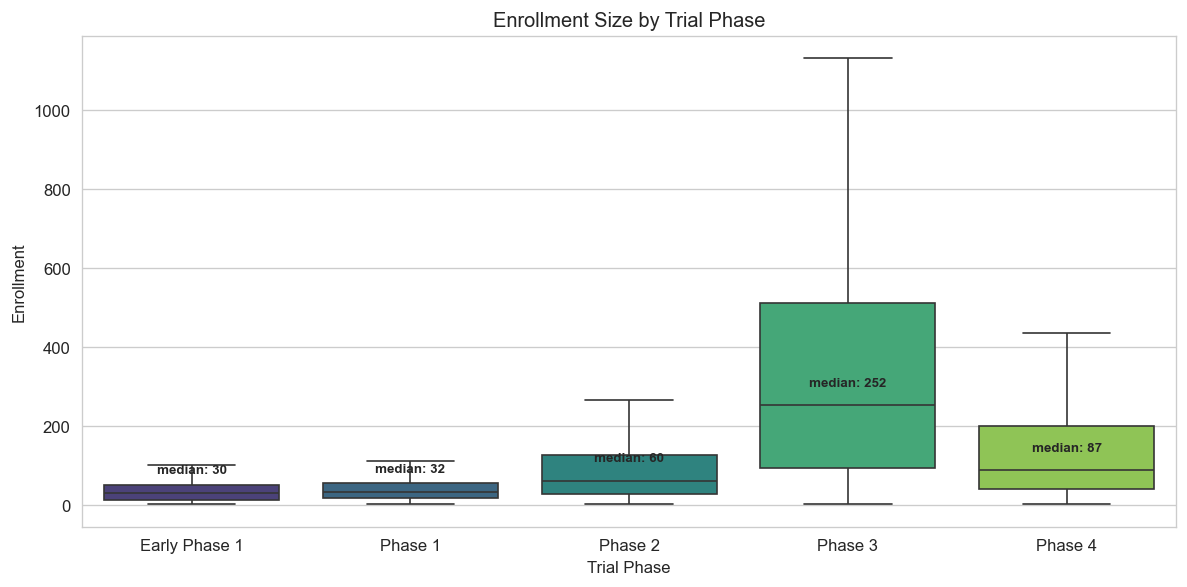

In [10]:
enroll = df[(df["phase_clean"] != "Not Specified") & (df["enrollment"].notna())].copy()
enroll["enrollment"] = pd.to_numeric(enroll["enrollment"], errors="coerce")
enroll = enroll[(enroll["enrollment"] > 0) & (enroll["enrollment"] < 50000)]

phase_order_box = ["Early Phase 1", "Phase 1", "Phase 2", "Phase 3", "Phase 4"]

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=enroll, x="phase_clean", y="enrollment", 
            order=phase_order_box, palette="viridis",
            showfliers=False, ax=ax)
ax.set_xlabel("Trial Phase")
ax.set_ylabel("Enrollment")
ax.set_title("Enrollment Size by Trial Phase")

# Add median labels
medians = enroll.groupby("phase_clean")["enrollment"].median().reindex(phase_order_box)
for i, med in enumerate(medians):
    ax.text(i, med + 50, f"median: {int(med)}", ha="center", fontsize=8, fontweight="bold")

plt.tight_layout()
plt.savefig("outputs/enrollment_by_phase.png", bbox_inches="tight")
plt.show()

## 9. Trending Conditions (2015–2025)

Which conditions have seen the biggest increase in research activity over the past decade?

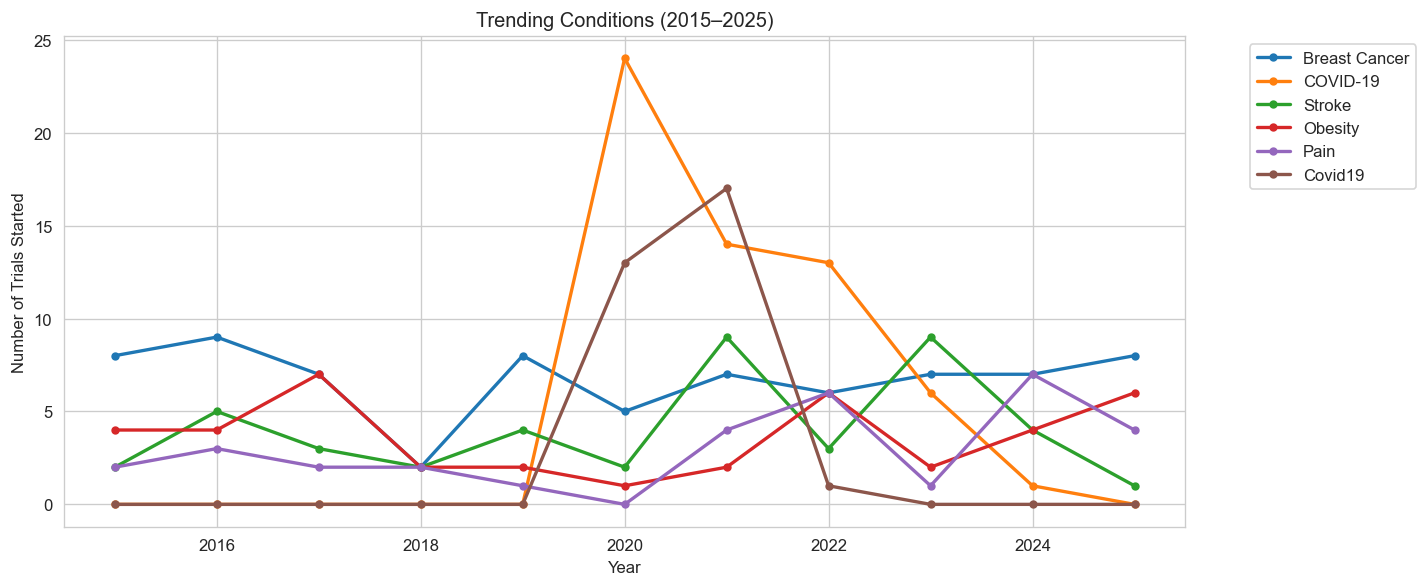

In [11]:
recent = df[(df["start_year"] >= 2015) & (df["start_year"] <= 2025)].copy()

# Get top conditions that have enough volume
top_conds = recent["condition"].value_counts().head(8).index.tolist()
# Remove 'Healthy' — it's a control group, not a disease
top_conds = [c for c in top_conds if c != "Healthy"][:6]

trend_data = recent[recent["condition"].isin(top_conds)].groupby(
    ["start_year", "condition"]
).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 5))
for condition in top_conds:
    if condition in trend_data.columns:
        ax.plot(trend_data.index, trend_data[condition], marker="o", 
                label=condition, linewidth=2, markersize=4)

ax.set_xlabel("Year")
ax.set_ylabel("Number of Trials Started")
ax.set_title("Trending Conditions (2015–2025)")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.savefig("outputs/trending_conditions.png", bbox_inches="tight")
plt.show()

## Key Takeaways

1. **Cancer dominates** — Breast cancer and prostate cancer are the most studied conditions, reflecting the large patient populations and funding priorities

2. **Academic institutions lead** — Universities and hospitals sponsor the majority of trials, but industry dominates the later phases (Phase 3/4) where commercialization is the goal

3. **The Phase 2 bottleneck** — Phase 2 has the most trials but a lower completion rate than Phase 3/4, reflecting the high failure rate at this stage of drug development

4. **US and China lead geographically** — Together they account for a disproportionate share of global trial activity, with France and Canada rounding out the top 4

5. **COVID-19's visible impact** — A clear spike in trial registrations around 2020–2021, with COVID-19 appearing among the top studied conditions despite only emerging in 2020